In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import statsmodels.api as sm

In [1]:


data = pd.read_csv('Preços_de_casas.csv')

Precificação valores de um casa utilizando regressão linear.
Utilizaremos conceitos de amostragem de dados e análise exploratória de dados.
Identificar como como algumas variáveis influenciam no valor de venda de uma casa.

In [ ]:
# Quais são os fatores que foram coletados a partir dos dados carregadO?
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1438 entries, 0 to 1437
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Id                              1438 non-null   int64  
 1   area_primeiro_andar             1438 non-null   float64
 2   existe_segundo_andar            1438 non-null   int64  
 3   area_segundo_andar              1438 non-null   float64
 4   quantidade_banheiros            1438 non-null   int64  
 5   capacidade_carros_garagem       1438 non-null   int64  
 6   qualidade_da_cozinha_Excelente  1438 non-null   int64  
 7   preco_de_venda                  1438 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 90.0 KB


In [6]:
data = data.drop(columns='Id')

In [7]:
# correlação dos vatores

corr = data.corr()

Intensidade: Refere-se à força da relação entre as variáveis medidas. 

- Pode variar de -1 a +1, onde -1 indica uma correlação perfeitamente negativa, +1 indica uma correlação perfeitamente positiva e 0 indica ausência de correlação linear.

        
Direção: Refere-se à natureza da relação entre as variáveis medidas. 

- Uma correlação positiva indica que as variáveis aumentam ou diminuem juntas. 
        
- Uma correlação negativa indica que uma variável aumenta enquanto a outra diminui, ou vice-versa.

In [8]:
# Para cada uma das colunas do conjunto, iremos retornar a correlação com a coluna de "preço de venda"
# quanto mais próximo dos extremos, mais correlacionado as variáveis estão com a variável analisada
#
corr['preco_de_venda']

area_primeiro_andar               0.616557
existe_segundo_andar              0.138541
area_segundo_andar                0.305311
quantidade_banheiros              0.563132
capacidade_carros_garagem         0.640214
qualidade_da_cozinha_Excelente    0.496223
preco_de_venda                    1.000000
Name: preco_de_venda, dtype: float64

Analizando o coeficiente de correlação linear entre as variáveis "capacidade_carros_garagem" e "preco_de_venda":

- Intensidade: O coeficiente de correlação linear é de 0.64, indicando uma correlação moderadamente forte; 

- direção: No geral, a medida que a capacidade de carros da garagem de uma casa aumenta, seu preço também tende a aumentar 

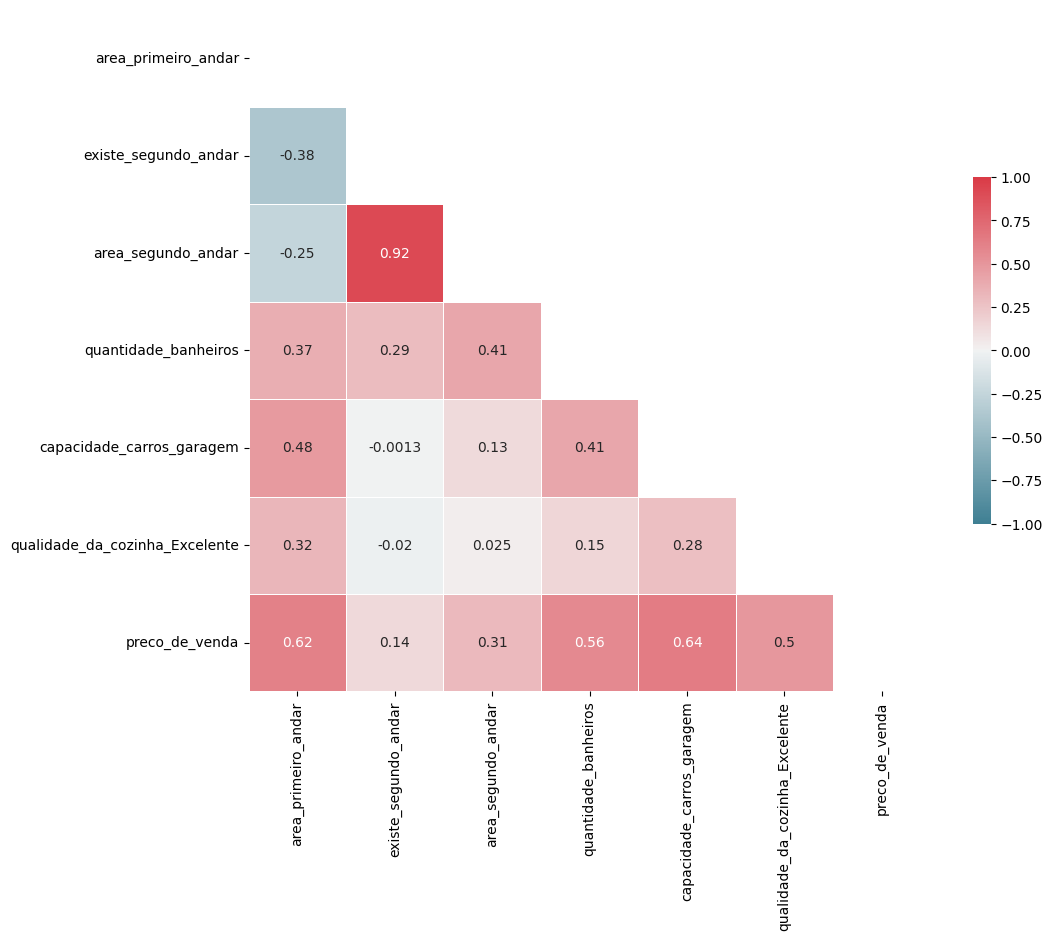

In [12]:
# Gerar uma máscara para o triângulo superior
mascara = np.zeros_like(corr, dtype=bool)
mascara[np.triu_indices_from(mascara)] = True

# Configurar a figura do matplotlib
f, ax = plt.subplots(figsize=(11, 9))

# Gerar o mapa de calor (heatmap)
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(corr, mask=mascara, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, annot=True, cbar_kws={"shrink": .5})

# Exibir o mapa de calor (heatmap)
plt.show()

In [ ]:
%pip install plotly

Text(0, 0.5, 'Preço de venda')

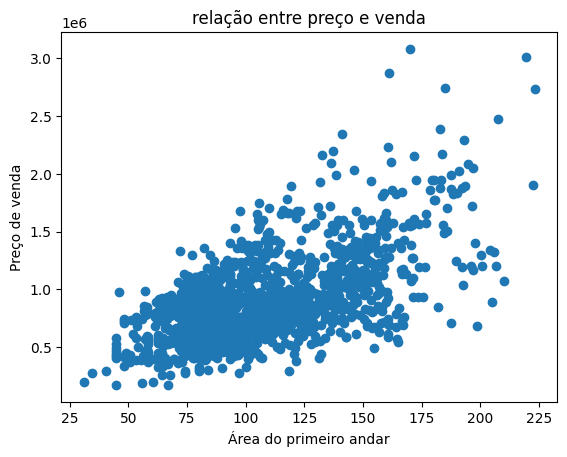

In [16]:
# aparentemente, quanto maior a area do primeiro andar, maior é o preço da casa.

plt.scatter(x = data['area_primeiro_andar'], y = data ['preco_de_venda'])

plt.title("relação entre preço e venda")
plt.xlabel("Área do primeiro andar")
plt.ylabel("Preço de venda")


Text(0, 0.5, 'Preço de venda')

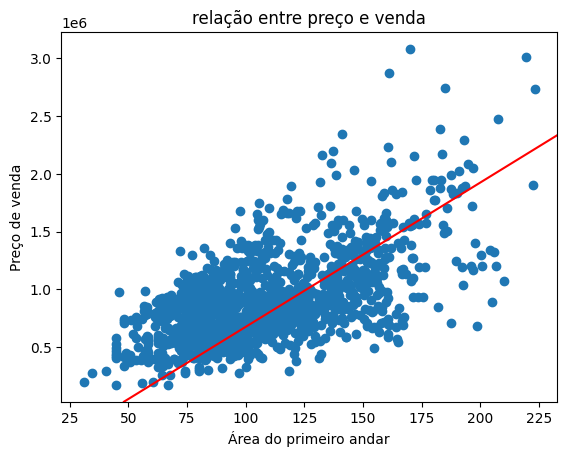

In [17]:
plt.scatter(x = data['area_primeiro_andar'], y = data ['preco_de_venda'])

# Abaixo traças uma linha através da marcação de dois pontos no gráfico, utilizando as coordenadas x e y.
# Os valores atribuídos são arbitrários e, nesse caso, são utilizados para analizar esses pontos
plt.axline(xy1 = (66,250000), xy2= (190, 1800000), color = "red")

plt.title("relação entre preço e venda")
plt.xlabel("Área do primeiro andar")
plt.ylabel("Preço de venda")

In [22]:
# Qual é a melhor reta que representa os meus dados?

px.scatter(data, x = "area_primeiro_andar", y = 'preco_de_venda', trendline_color_override= 'red', trendline= 'ols')

-  Elencamos uma variável explicativa
- Elencamos uma variável 
- a representação linear possuyi uma formula que é Yi = Bo + B1*Xi
- Com isso, podemos definir o preço de venda a partir da área do primeiro andar

O QUE APRENDEMOS NESSA AULA:
- Obter o coeficiente de correlação dos dados;
- Analisar a intensidade e a direção da correlação entre duas variáveis;
- Identificar linearidade no gráfico de dispersão;
- Diferenciar variável explicativa de variável resposta;
- Visualizar a melhor reta utilizando o Plotly.